In [76]:
!pip install mglearn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# 지도학습 - 선형회귀 (Linear Regression)

회귀 모델이란?

- 어떤 자료에 대해서 그 값에 영향을 주는 조건을 고려하여 구한 평균 <br>
(어떤 데이터들이 굉장히 크거나 작을지라도 전체적으로 이 데이터들은 전체 평균으로 회귀하려는 특징이 있다는 통계학 기법)


- \\( y = h(x_1, x_2, x_3, ..., x_k; W_1, W_2, W_3, ..., W_k) + \epsilon \\)

 - h() : 조건에 따른 평균을 구하는 함수 (회귀 모델)
 - x : 어떤 조건(특성)
 - W : 각 조건의 영향력(가중치)
 - e : ‘오차항’을 의미. 다양한 현실적인 한계로 인해 발생하는 불확실성으로 일종의 잡음(noise)

선형 모델이란?

- 입력 특성에 대한 선형 함수를 만들어 예측을 수행

- 다양한 선형 모델이 존재

- 분류와 회귀에 모두 사용 가능


<center>

시험성적 데이터

|X ( 학습 시간 )| Y ( 시험 점수 )|
|---|---|
|9 |90|
|8 |80|
|4| 40|
|2| 20|

7시간 공부 할 경우 성적은?
</center>



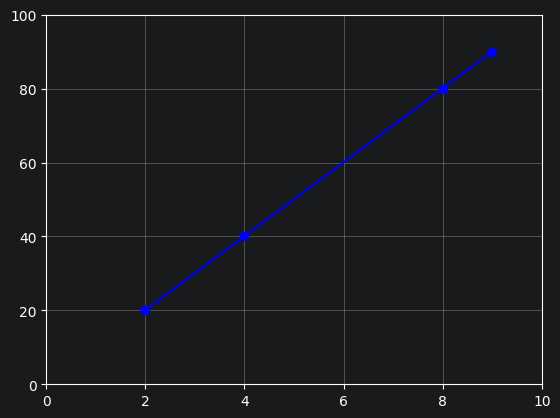

In [77]:
import matplotlib.pyplot as plt
%matplotlib inline

x = [9, 8, 4, 2]
y = [90, 80, 40, 20]

plt.xlim(0, 10)
plt.ylim(0, 100)
plt.plot(x, y, 'b-o')
plt.grid()
plt.show()

 \\( y=ax+b \\)

 - a : 기울기
 - b : 절편

<center>

시험성적 데이터

|X ( 학습 시간 )| Y ( 시험 점수 )|
|---|---|
|8 |97|
|6 |91|
|4| 93|
|2| 81|

7시간 공부 할 경우 성적은?
</center>



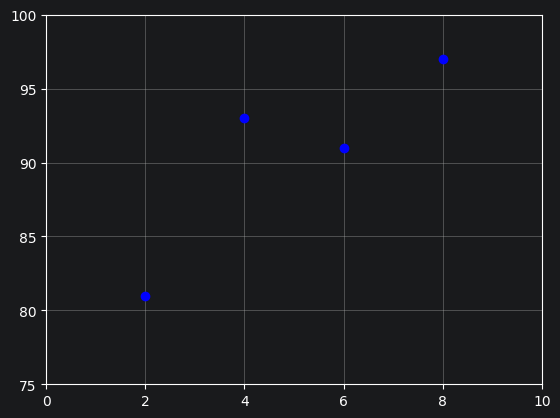

In [78]:
import matplotlib.pyplot as plt
%matplotlib inline

x = [8, 6, 4, 2]
y = [97, 91, 93, 81]

plt.xlim(0, 10)
plt.ylim(75, 100)
plt.plot(x, y, 'bo')
plt.grid()
plt.show()

 \\( y=ax+b \\)

 - a : 기울기
 - b : 절편

최소제곱법

> \\( a=\frac { (x-x평균)(y-y평균)의 합 }{ { (x-x평균) }^{ 2 }의 합 }  \\)

- 공부한 시간(x)의 평균: (2+4+6+8) / 4 = 5
- 성적(y)의 평균: (81+93+91+97) / 4 = 90.5

> \\( b=y의 평균- (x의 평균 \times 기울기 a) \\)

- b = 90.5 - (5 x 2.3) = 79


In [79]:
a = ( (2-5)*(81-90.5)+(4-5)*(93-90.5)+(6-5)*(91-90.5)+(8-5)*(97-90.5) )  /  ( (2-5)**2 + (4-5)**2 + (6-5)**2 + (8-5)**2 )
a1 = ( (2-5)*(81-90.5)+(4-5)*(93-90.5)+(6-5)*(91-90.5)+(8-5)*(97-90.5) ) 
a2 = ( (2-5)**2 + (4-5)**2 + (6-5)**2 + (8-5)**2 )
a1, a2, a

(46.0, 20, 2.3)

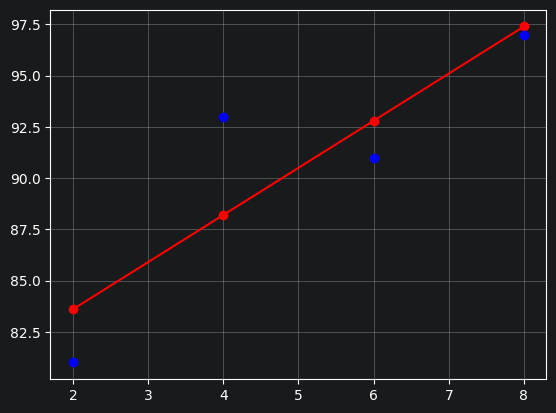

In [80]:
# 오차가 최저가 되는 직선
import numpy as np
# 기울기 a를 최소제곱법으로 구하는 함수
def compute_a(x, y, mean_x, mean_y):
  # 분자부분
  dc = 0
  for i in range(len(x)):
    dc += (x[i] - mean_x) * (y[i] - mean_y)
  
  # 분모부분
  divisor = sum([(i - mean_x)**2  for i in x])

  a = dc / divisor
  return a

x = [8, 6, 4, 2]
y = [97, 91, 93, 81]
mx = np.mean(x)
my = np.mean(y)
a = compute_a(x, y, mx, my)  # 기울기
b = my - (mx * a)            # 절편

y_pred = [a * x1 + b  for x1 in x]

plt.plot(x, y_pred, 'r-o')
plt.plot(x, y, 'bo')
plt.grid()
plt.show()

## 선형회귀(Linear Regression) <br>
 또는 최소제곱법(Ordinary Least Squares)

- 종속변수(응답변수) y와 한 개 이상의 독립변수(입력변수) x와의 상관관계를 모델링한 것

 >  \\( y=Wx+b \\)  
  - (W : 가중치, b : 편향(bias))

 > \\( H(x)=Wx+b \\)  
  - H(x) : Linear 하게 Hypothesis(가설)을 세운다는 것
  - 데이터를 가장 잘 대변할 수 있는 H(x)의 W와 b를 정하는 것이 Linear Regression의 목적

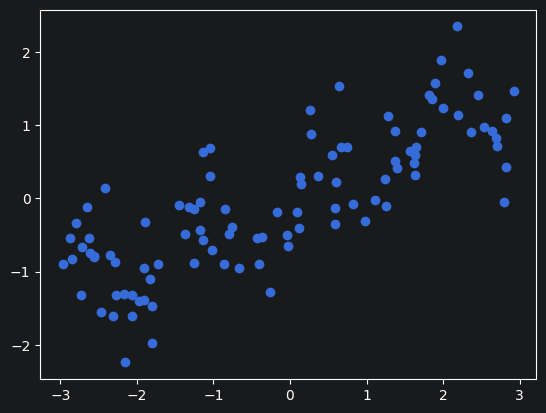

In [81]:
import numpy as np
import mglearn

X, y = mglearn.datasets.make_wave(100)

plt.scatter(X, y)
plt.show()

w[0]: 0.393906  b: -0.031804


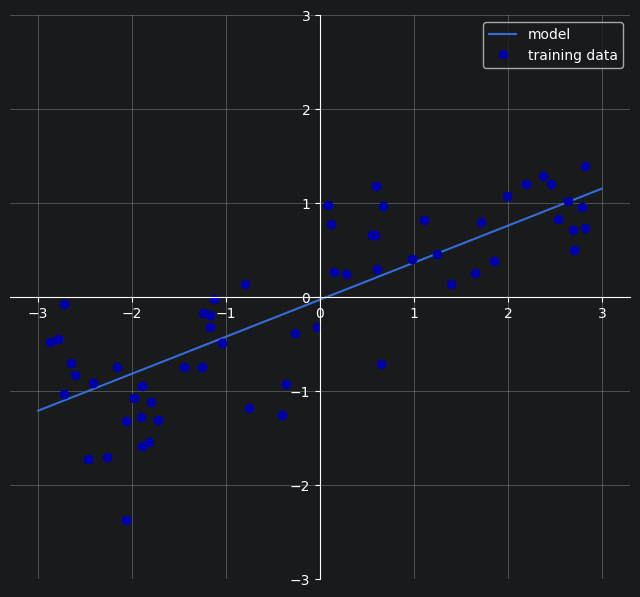

In [82]:
import mglearn
mglearn.plots.plot_linear_regression_wave()

- 비용함수 (Cost / Cost function) : 그려진 직선 Hypothesis(H(x))와 실제 데이터(y)의 차이

  - Cost = H(x) - y에 데이터를 대입하여 Cost의 총합을 구하는 것이 가능
  - Cost의 총합이 작은 Hypothesis일수록 데이터를 잘 대변하는 훌륭한 Linear Regression
  - Cost는 양수일 수도, 음수일 수도 있기에 이러한 문제를 방지하고자 총합을 구할 때 Cost값을 제곱하여 평균을 내는 방식(평균제곱오차, MSE, Mean Squared Error)을 사용
  >  \\( cost(W,b)=\cfrac { 1 }{ m } \sum _{ i=1 }^{ m } { (H({ x }^{ (i) })-{ y }^{ (i) }) }^{ 2 }  \\)

   > \\( H(x)=Wx+b \\)  

 - 머신러닝(or 딥러닝)에서 learning의 목적은 Cost를 정의하고 이를 최소화하는 것

#### 평균제곱오차 (MSE, Mean Squared Error) - 잘못그은 선 바로잡기

- 실제값과 예측값의 차이를 분석하기 위한 것
- 음수가 존재하는 경우 오차가 줄어드는 문제 -> 자승을 취함
- 평균오차가 자승으로 인해 커지는 문제 -> 제곱근을 취함

|x(hour) | y(score)|
|---|---|
|0|0|
|1|1|
|2|2|
|3|3|

\\( H(x)=1 \times  x+0 \\)  

\\( H(x)=0.5 \times x+0 \\)  

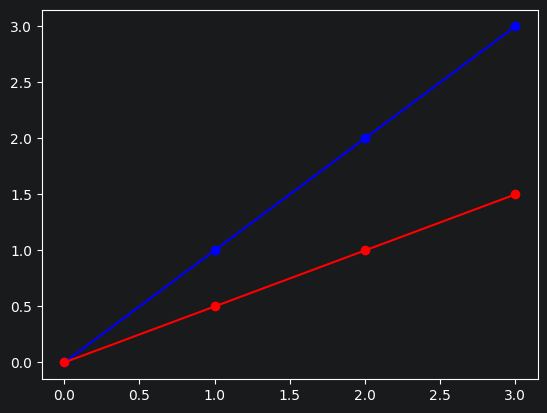

In [83]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

x = np.array([0, 1, 2, 3])
y = np.array([0, 1, 2, 3])

# 가중치(계수) 및 편향(절편)
w = 1
b = 0
y_pred1 = w * x + b
plt.plot(x, y_pred1, 'b-o')

w = 0.5
b = 0
y_pred2 = w * x + b
plt.plot(x, y_pred2, 'r-o')


#### 평균제곱오차 (MSE, Mean Squared Error) 연습 01
가설의 MSE 값을 계산해보자.


\\( \cfrac { { (H({ x }^{ (1) })-{ y }^{ (1) }) }^{ 2 } + { (H({ x }^{ (2) })-{ y }^{ (2) }) }^{ 2 }+ { (H({ x }^{ (3) })-{ y }^{ (3) }) }^{ 2 }+ { (H({ x }^{ (4) })-{ y }^{ (4) }) }^{ 2 } }{ 4 } = ? \\)

In [84]:
# y_pred(예측값), y(실제값)
def MSE(y_pred, y):
  cost = np.sum((y_pred - y)**2) / len(y)
  return cost

MSE(y_pred1, y), MSE(y_pred2, y)

(np.float64(0.0), np.float64(0.875))

#### 경사하강법 (Gradient descent algorithm) - 오차 수정하기

어떻게 비용함수 값이 최소가 되는 W 파라미터를 구할 수 있을까?

- 점진적인 하강, 점진적으로 반복적인 계산을 통해 W 파라미터 값을 업데이트 하면서 오류 값이 최소가 되는 값을 구하는 방식

- 함수의 기울기(경사)를 구하여 기울기가 낮은 쪽으로 
계속 이동하여 값을 최적화 시키는 방법 <br> (오차 (기울기)가 가장 작은 방향으로 이동시키는 방법)


learning_rate(학습 속도)란?

- W와 b의 미분 값(W_grad, b_grade)을 얼마만큼 반영할지를 결정하는 값.
- 주로 0.001, 0.00001과 같은 매우 작은 값을 사용하며 learning_rate가 클수록 변화가 빠르며, learning_rate가 작을수록 변화가 느리다고 예상.
- 꼭 변화가 빠르다고 해서 결과를 빨리 볼 수 있는 것은 아님.

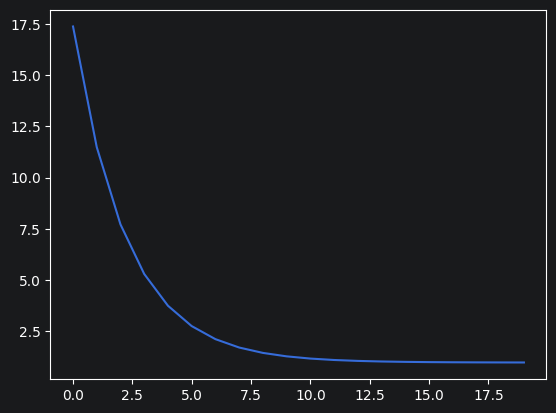

In [85]:
import numpy as np
import matplotlib.pyplot as plt
w_val = []
cost_val = []
xx_val = []

n_samples = 200
x = np.random.randn(n_samples)
y = 2 * x + 4 + np.random.randn(n_samples)
# plt.scatter(x, y)

n_epoch = 20  # 반복횟수
lr = 0.2      # 학습속도

w = np.random.uniform()
b = np.random.uniform()

for epoch in range(n_epoch):
  y_pred = w * x + b
  cost = MSE(y_pred, y)
  xx = lr * ((y_pred - y) * x).mean()
  # print(f'{epoch:3} w={w:.6f}, b={b:.6f}, cost={cost:.6f}, lr*((y_pred-y)*x).mean()={xx:.6f}')

  w = w - xx
  b = b - lr * (y_pred - y).mean()
  
  w_val.append(w)
  cost_val.append(cost)
  xx_val.append(xx)

plt.plot(range(n_epoch), cost_val)
plt.show()

#### LinearRegression 실습 01

배달시간 예측
- 설정 거리의 장소에 배달하려면 얼마나 걸리는지 예측

In [86]:
import numpy as np 
from matplotlib import pyplot as plt 

In [87]:
# 배달거리와 배달시간 데이터
data = np.array([
    [100, 20], 
		[150, 24], 
		[300, 36], 
		[400, 47], 
		[130, 22], 
		[240, 32],
		[350, 47], 
		[200, 42], 
		[100, 21], 
		[110, 21], 
		[190, 30], 
		[120, 25], 
		[130, 18], 
		[270, 38], 
		[255, 28]])

x = data[:, 0]
y = data[:, 1]

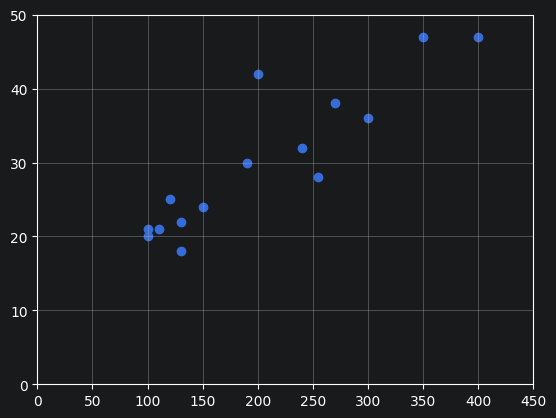

In [88]:
plt.xlim(0, 450)
plt.ylim(0, 50)
plt.grid()
plt.scatter(x, y)

In [89]:
# 기울기 a를 최소제곱법으로 구하는 함수
def compute_a(x, y, mean_x, mean_y):
    dc = sum([(x[i]-mean_x)*(y[i]-mean_y) for i in range(len(x))]) # 분자 부분
    d = sum([(x[i]-mean_x)**2 for i in range(len(x))]) # 분모 부분  
    return dc / d

mx = np.mean(x)
my = np.mean(y)
a = compute_a(x, y, mx, my)  # 기울기
b = my - (mx * a)            # 절편
a, b

(np.float64(0.09229753862877554), np.float64(11.330266325025232))

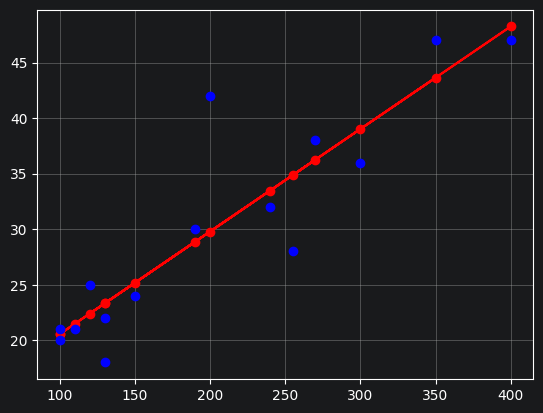

In [90]:
y_pred = [a * x1 + b for x1 in x]
plt.plot(x, y_pred, 'r-o')
plt.plot(x, y, 'bo')
plt.grid()
plt.show()

- 예측하기 (거리가 350인경우 배달시간)

In [91]:
t = a * 350 + b
t

np.float64(43.63440484509667)

#### 일반 선형회귀

예측값과 실제 값의 cost를 최소화할 수 있도록 W(가중치, 회귀계수)를 최적화하며, 규제(Regularization)를 적용하지 않은 모델

단순 선형회귀 (Simple Linear Regression)
> \\( H({ x })={ W }{ x }+b \\)

다변수 선형회귀 (Multi-variable Linear Regreesion)
> 변수가 3개 일때의 H(x) <br>
> \\( H({ x }_{ 1 },{ x }_{ 2 },{ x }_{ 3 })={ W }_{ 1 }{ x }_{ 1 }+{ W }_{ 2 }{ x }_{ 2 }+{ W }_{ 3 }{ x }_{ 3 }+b \\)

> 변수가 n개 일때의 H(x) <br>
>  \\( H({ x }_{ 1 },{ x }_{ 2 },{ x }_{ 3 },\dots ,{ x }_{ n })={ W }_{ 1 }{ x }_{ 1 }+{ W }_{ 2 }{ x }_{ 2 }+{ W }_{ 3 }{ x }_{ 3 }+\dots +{ W }_{ n }{ x }_{ n }+b \\)

다항 회귀 (Polynomial Regreesion)
> 회귀가 독립변수의 단항식이 아닌 2차, 3차 방정식과 같은 다항식으로 표현되는 것 <br>
> 차수가 높아질수록 과적합의 문제가 발생


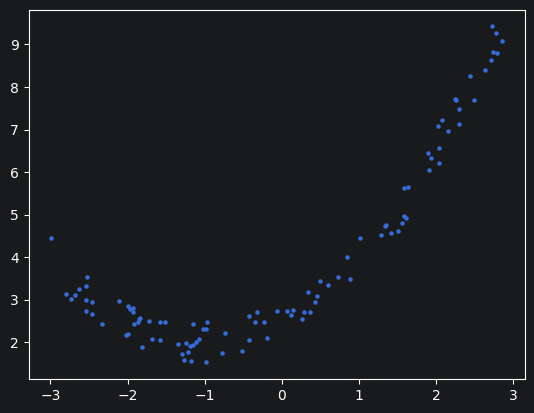

In [92]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

n = 100
x = 6 * np.random.rand(n, 1) - 3
y = 0.5 * x**2 + 1 * x + 2 + np.random.rand(n, 1)

plt.scatter(x, y, s=5)

In [93]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
x_poly = poly_features.fit_transform(x)
x.shape, x_poly.shape

((100, 1), (100, 2))

In [94]:
from re import L
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_poly, y)
model.coef_, model.intercept_
# y = 0.5 * x**2 + 1 * x + 2

(array([[1.0037498 , 0.48406376]]), array([2.54299633]))

#### LinearRegression 실습 02

wave 데이터셋에 선형회귀 적용

LinearRegression()
```
LinearRegression(fit_intercept, normalize, copy_X, n_jobs)
```
- fit_intercept : 모형에 상수항 (절편)이 있는가 없는가를 결정하는 인수 (default : True)
- normalize : 매개변수 무시 여부
- copy_X : X의 복사 여부
- n_jobs : 계산에 사용할 작업 수

In [95]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import mglearn

X, y = mglearn.datasets.make_wave(60)
# plt.scatter(X, y)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
print('가중치(계수, 기울기, w):', model.coef_)
print('편향(절편, b):', model.intercept_)

print('훈련 점수:', model.score(X_train, y_train))
print('테스트 점수:', model.score(X_test, y_test))

가중치(계수, 기울기, w): [0.39390555]
편향(절편, b): -0.031804343026759746
훈련 점수: 0.6700890315075756
테스트 점수: 0.65933685968637


#### LinearRegression 실습 03 - 1
변수가 1개인 경우

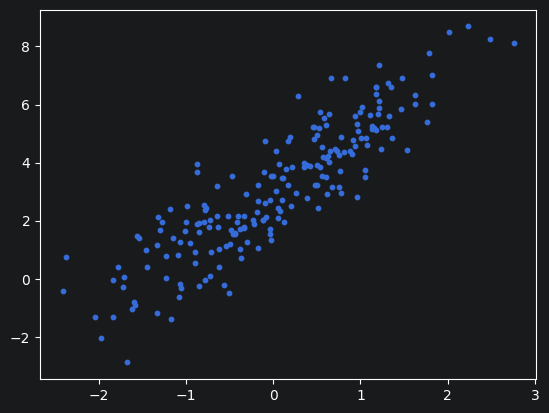

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

n_samples = 200
x = np.random.randn(n_samples)
w = 2
b = 3
y = w * x + b + np.random.randn(n_samples)
plt.scatter(x, y, s=10)

In [97]:
from sklearn.linear_model import LinearRegression

X = x.reshape(-1, 1)
model = LinearRegression()
model.fit(X, y)
model.coef_, model.intercept_

(array([1.99232106]), np.float64(3.031559606887346))

#### LinearRegression 실습 03 - 2
변수가 2개인 경우

다변수 선형 회귀 (Multi-variable Linear Regreesion)



In [98]:
# 주어진 x1, x2, y를 가지고 선형모델 적용 후 가중치와 편향을 출력해 보세요.
n_samples = 200
x1 = np.random.randn(n_samples)
x2 = np.random.randn(n_samples)
y = 2 * x1 + 3 * x2 + 4 + np.random.randn(n_samples)

X = pd.DataFrame({'x1':x1, 'x2':x2})
X.head
# X = np.hstack( (x1.reshape(-1, 1), x2.reshape(-1, 1)) )
# X.shape
model = LinearRegression()
model.fit(X, y)
model.coef_, model.intercept_

(array([1.96560956, 2.95878236]), np.float64(3.9594782421840695))

#### LinearRegression 실습 04

보스턴 집값 데이터셋 구성
- 506개의 데이터
- 13개의 정보와 1개의 클래스로 구성
```
0 CRIM : 인구 1인당 범죄 발생 수
1 ZN : 25,000평방 피트 이상의 주거 구역 비중
2 INDUS : 소매업 외 상업이 차지하는 면적 비율
3 CHAS : 찰스강 위치 변수 (1: 강 주변, 0: 이외)
4 NOX : 일산화질소 농도
5 RM : 집의 평균 방 수
6 AGE : 1940년 이전 지어진 비율
7 DIS : 5가지 보스턴 시 고용 시설까지의 거리
8 RAD : 순환고속도로의 접근 용이성
9 TAX : $10,000당 부동산 세율 총계
10 PTRATIO : 지역별 학생과 교사 비율
11 B : 지역별 흑인 비율
12 LSTAT : 급여가 낮은 직업에 종사하는 인구 비율 (%)
13 MEDV : 가격 (단위 : $1,000)
```

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [100]:
import pandas as pd
import numpy as np
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None) # r"\s+"
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

In [101]:
# 데이터 세트 DataFrame 변환
columns = ['CRIM','ZN','INDUS','CHAS','NOX','RM','AGE','DIS','RAD','TAX','PTRATIO','B','LSTAT','PRICE']
df = pd.DataFrame(data, columns=columns[:-1])
df['PRICE'] = target
df.head(3)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7


In [102]:
# 훈련 데이터와 테스트 데이터 준비
from sklearn.model_selection import train_test_split
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [103]:
# 모델 선택과 학습
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
print('훈련 점수:', model.score(X_train, y_train) )
print('테스트 점수:', model.score(X_test, y_test) )

훈련 점수: 0.7697699488741149
테스트 점수: 0.6354638433202133


In [104]:
# 예측/평가(회귀)
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2score = r2_score(y_test, y_pred)

print(f'MSE={mse:.3f}, RMSE={rmse:.3f}, R2SCORE={r2score:.3f}')

MSE=29.782, RMSE=5.457, R2SCORE=0.635


In [105]:
# "가중치(계수, 기울기 파라미터 W) :"  # N 소수점 자릿수까지 반올림
print("가중치(계수, 기울기 파라미터 W) :", np.round(model.coef_, 1))
print("편향(절편 파라미터 b) :", model.intercept_)

# 특성(피처)별 회귀 계수 값 순으로 출력
coeff = pd.Series(data=np.round(model.coef_, 1), index=X.columns)
coeff.sort_values(ascending=False)

가중치(계수, 기울기 파라미터 W) : [ -0.1   0.   -0.    2.4 -15.6   3.8  -0.   -1.4   0.2  -0.   -1.    0.
  -0.5]
편향(절편 파라미터 b) : 36.933255457118975


RM          3.8
CHAS        2.4
RAD         0.2
INDUS      -0.0
ZN          0.0
B           0.0
TAX        -0.0
AGE        -0.0
CRIM       -0.1
LSTAT      -0.5
PTRATIO    -1.0
DIS        -1.4
NOX       -15.6
dtype: float64

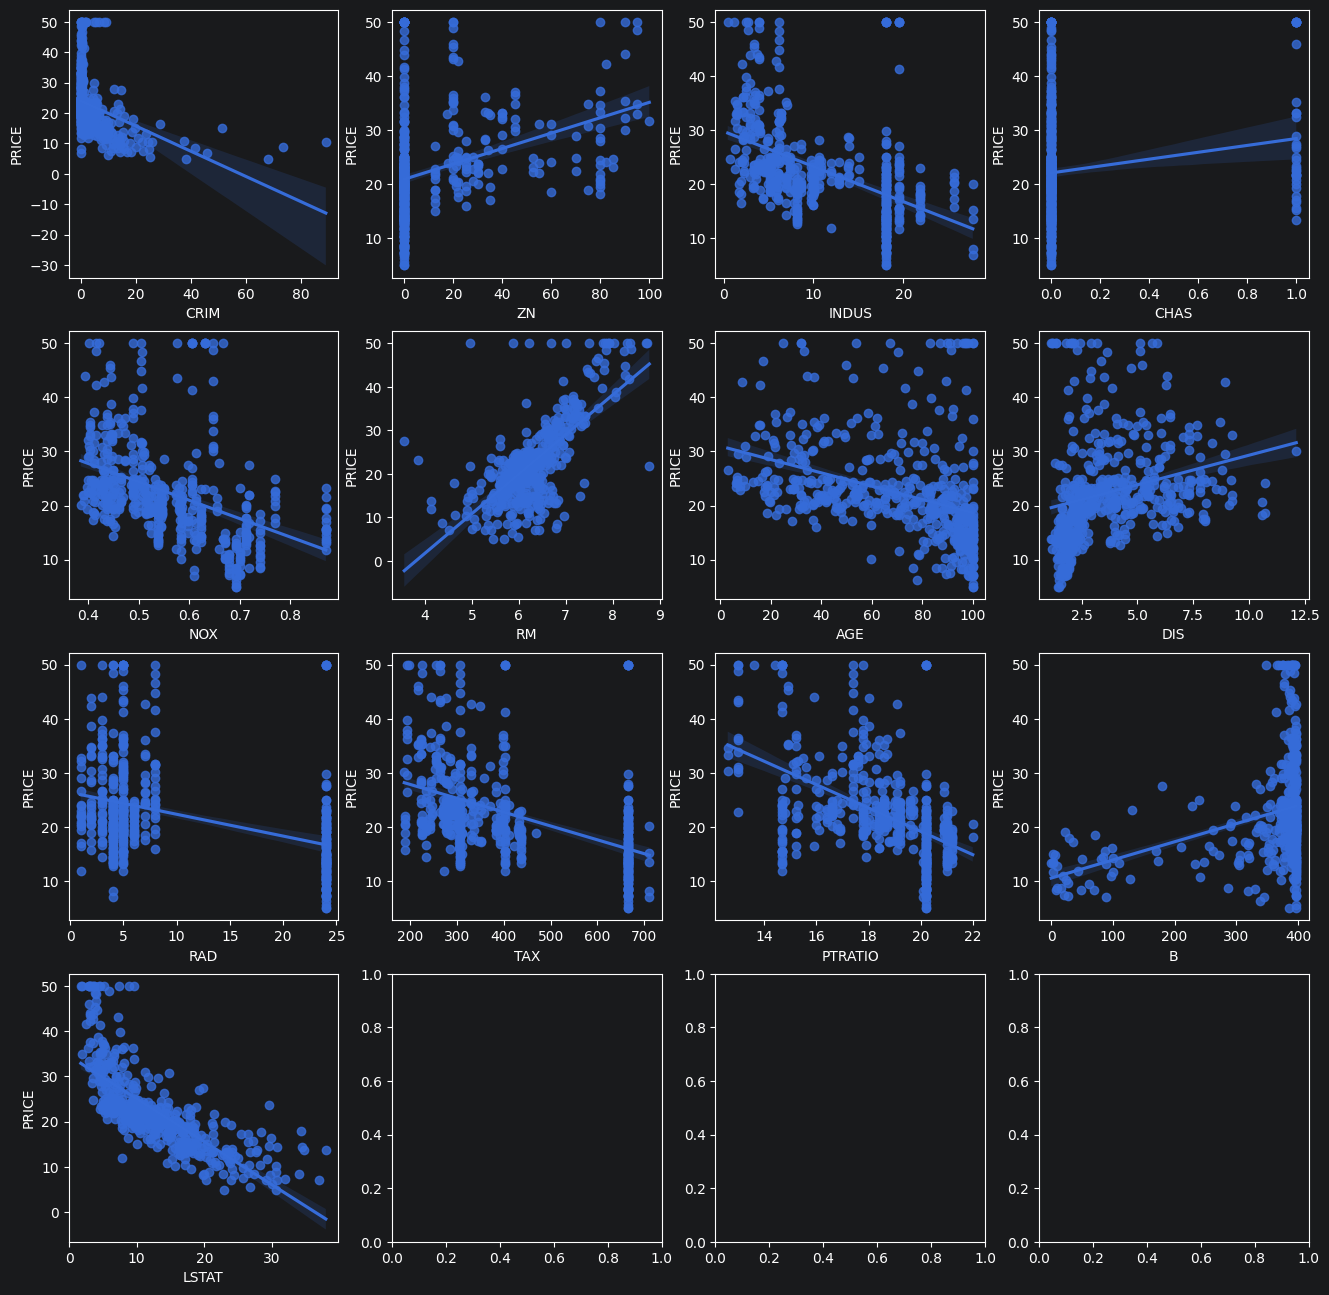

In [106]:
# 데이터 조사
# 시각화
# 4행 4열, axes는 4x4 개의 ax를 갖음
# 시본의 regplot을 이용해 산점도와 선형 회귀 직선을 함께 표현
fig, axes = plt.subplots(4, 4, figsize=(16, 16) )
for i, feature in enumerate(X.columns):
  row = int( i / 4 )
  col = i % 4
  sns.regplot(x=feature, y='PRICE', data=df, ax=axes[row][col] )

#### LinearRegression 실습 05

유방암 데이터셋에 선형회귀 적용

In [107]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [108]:
X = cancer.data
y = cancer.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [109]:
model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_train, y_train)

0.7824123695930644

In [110]:
model.score(X_test, y_test)

0.7291758706114018

#### LinearRegression 실습 06

확장 보스턴 집값 셋에 선형회귀 적용

In [111]:
# from sklearn.datasets import load_boston
X, y = mglearn.datasets.load_extended_boston()


In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [113]:
model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_train, y_train)

0.952051960903273

In [114]:
model.score(X_test, y_test)

0.6074721959665883

#### LinearRegression 실습 07

붓꽃 데이터 셋에 선형회귀 적용

In [115]:
from sklearn.datasets import load_iris

iris = load_iris()
#sepal 꽃밭침
#petal 꽃잎
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

꽃받침 길이와 꽂잎 길이를 이용한 선형회귀

In [116]:
X = iris.data[:, 0] # 꽃받침 길이
y = iris.data[:, 2] # 꽃잎 길이

In [117]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X.reshape(-1, 1), 
                                                    y,
                                                    random_state=0)
X_train.shape

(112, 1)

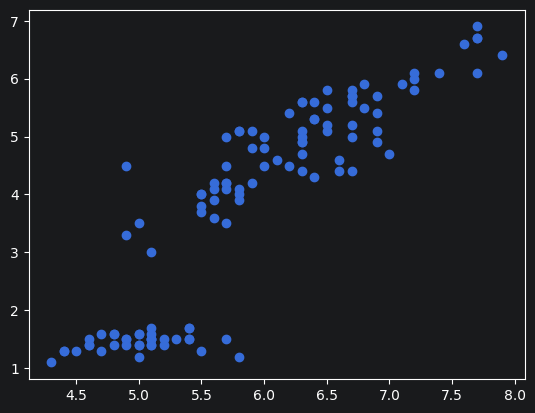

In [118]:
%matplotlib inline
import matplotlib.pyplot as plt

#두 가지 특성을 시각화 
plt.scatter(X_train, y_train)

In [119]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_train, y_train)

0.7864459990171913

In [120]:
model.score(X_test, y_test)

0.6634802872219326

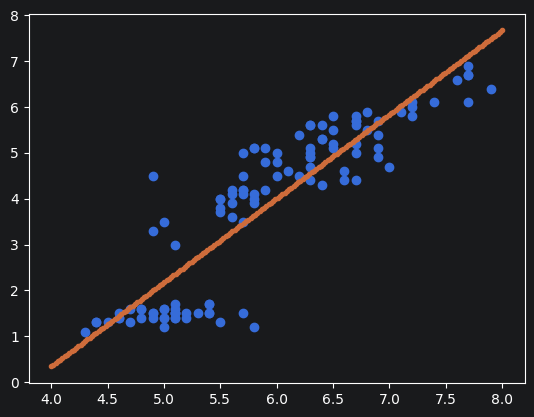

In [121]:
plt.scatter(X_train, y_train)
xx = np.linspace(4, 8, 200)
yy = model.coef_ * xx + model.intercept_
plt.scatter(xx, yy, marker='.')

꽃잎 길이와 꽂잎 너비를 이용한 선형회귀

In [122]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [123]:
X = iris.data[:, 2] # 꽃잎 길이
y = iris.data[:, 3] # 꽃잎 너비

In [124]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X.reshape(-1, 1), 
                                                    y,
                                                    test_size=0.2,
                                                    random_state=0)
X_train.shape

(120, 1)

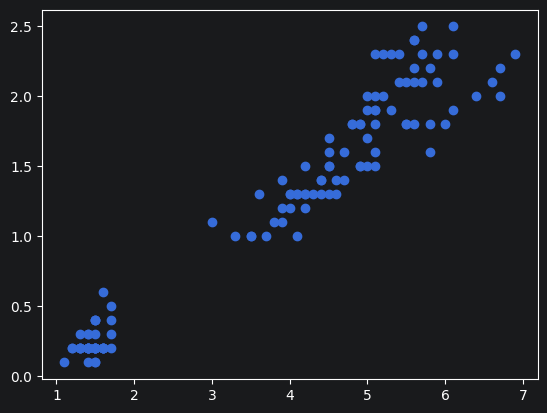

In [125]:
%matplotlib inline
import matplotlib.pyplot as plt

#두 가지 특성을 시각화 
plt.scatter(X_train, y_train)

In [126]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_train, y_train)

0.9373993040848391

In [127]:
model.score(X_test, y_test)

0.8714094238773379

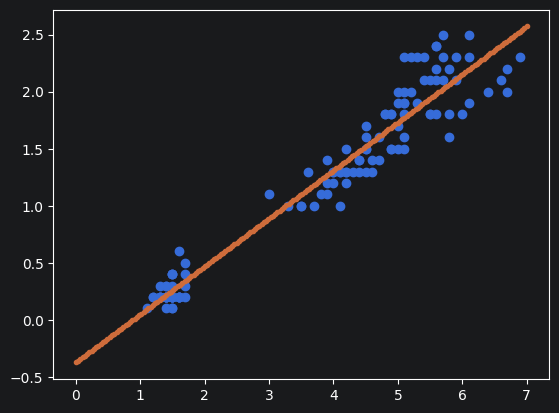

In [128]:
plt.scatter(X_train, y_train)
xx = np.linspace(0, 7, 200)
yy = model.coef_ * xx + model.intercept_
plt.scatter(xx, yy, marker='.')

장단점

- k-NN에 비해 더 제약이 있는 것처럼 보이지만 특성이 많은 데이터셋의 경우에는 우수한 성능을 낼 수 있다.
- 모델의 복잡도를 제어할 방법이 없어 과대적합 되기 쉽다.


Next. 모델 정규화(Regularization, 규제)을 통해 과대적합을 제어